In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.


['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
# Import libaries
import os
import time
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from keras.models import Sequential,load_model 
from keras.layers import Dense,Conv2D,Dropout,MaxPooling2D,Flatten
from keras.callbacks import EarlyStopping


2026-01-07 04:06:48.022548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767758808.035914      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767758808.039983      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 04:06:48.056477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
train_path='../input/train/train'
test_path='../input/test/test'


In [4]:
# Prepare train data 
label_train=pd.read_csv("../input/train.csv")
# Ordino il file in base all'id
label_train=label_train.sort_values(by=['id'])
# Creo 2 array distinti uno per gli id e l'altro per i label
id=label_train['id'].values
l=label_train['has_cactus'].values

train=[]
X=[]
Y=[]
a=0

for i in tqdm(sorted(os.listdir(train_path))):
    path=os.path.join(train_path,i)
    i=cv2.imread(path,cv2.IMREAD_COLOR)
    X.append(i)
    train.append([np.array(i),l[a]])
    a=a+1

train=np.array(train)
Y=train[:,1]
train=train[:,0]
X=np.array(X)

X.shape

X=X/255
train=train/255


100%|█████████▉| 14175/14176 [00:02<00:00, 6302.36it/s]


IndexError: index 14175 is out of bounds for axis 0 with size 14175

IndexError: list index out of range

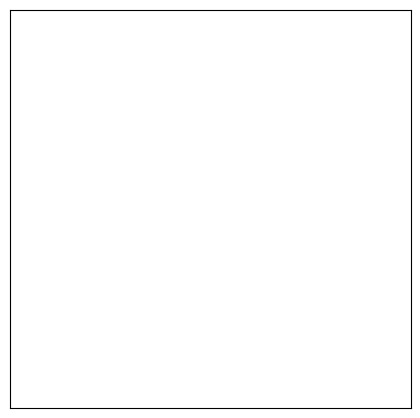

In [5]:
# Plot the first 25 images in Training Set 
plt.figure(figsize = (30,30))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    if Y[i]==1:
        l="Has Cactus"
    elif Y[i]==0:
        l="No Cactus"
    plt.xlabel(l,fontsize=25)
    plt.imshow(train[i])
plt.suptitle("First 25 images in Training Set ",fontsize=30)


In [6]:
# Prepare Test data 
test_viz=[]
X_test=[]

for i in tqdm(os.listdir(test_path)):
    id=i
    path=os.path.join(test_path,i)
    i=cv2.imread(path,cv2.IMREAD_COLOR)
    X_test.append(i)
    test_viz.append([np.array(i),id])

X_test=np.array(X_test)
X_test.shape
test_viz=np.array(test_viz)
id_test=test_viz[:,1]
test_viz=test_viz[:,0]
test_viz.shape

X_test=X_test/255
test_viz=test_viz/255


100%|██████████| 3326/3326 [00:00<00:00, 9344.07it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3326,) + inhomogeneous part.

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

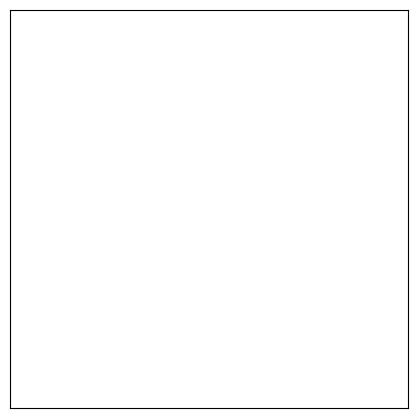

In [7]:
# Plot the first 25 images in Test Set 
plt.figure(figsize = (30,30))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_viz[i])
plt.suptitle("First 25 images in Testing Set ",fontsize=30)


In [8]:
# Creation of the model (cactus_identifier_net1)
m=Sequential()
m.add(Conv2D(filters=128,kernel_size=2,padding="same",activation="relu",input_shape=(32,32,3)))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=64,kernel_size=2,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=32,kernel_size=2,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Flatten())
m.add(Dense(32,activation="relu"))
m.add(Dropout(0.7))
m.add(Dense(1,activation="sigmoid"))
m.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-07 04:06:57.440923: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767758817.441395      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 26912)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       861,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,969 (3.45 MB)

 Trainable params: 903,969 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# training of the model
el=EarlyStopping(min_delta=0.001,patience=5)
m.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
s=time.time()
h=m.fit(X,Y,batch_size=256,validation_split=0.2,epochs=100,callbacks=[el])
e=time.time()
t=e-s
print("Addestramento completato in %d minuti e %d secondi" %(t/60,t*60))


AttributeError: 'NoneType' object has no attribute 'shape'

In [10]:
acc=h.history['acc']
val_acc=h.history['val_acc']
loss=h.history['loss']
val_loss=h.history['val_loss']


NameError: name 'h' is not defined

In [11]:
plt.plot(acc)
plt.plot(val_acc)
plt.title('Cactus_identifier_net1 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()


NameError: name 'acc' is not defined

In [12]:
plt.plot(loss)
plt.plot(val_loss)
plt.title('Cactus_identifier_net1 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()


NameError: name 'loss' is not defined

In [13]:
pred=m.predict(X_test)
ids=[]
label=[]
a=0
for i in tqdm(os.listdir(test_path)):
    id=i
    ids.append(id)
    label.append(pred[a])
    a=a+1

label=np.array(label,dtype='float64')
out=pd.DataFrame({'id': ids,'has_cactus':label[:,0]})

out.to_csv('cactus_identifier_net1.csv',index=False,header=True)


AttributeError: 'NoneType' object has no attribute 'shape'

In [14]:
# Craetion of the model (cactus_identifier_net2)
m=Sequential()
m.add(Conv2D(filters=128,kernel_size=2,padding="same",activation="relu",input_shape=(32,32,3)))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=64,kernel_size=2,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=32,kernel_size=2,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Flatten())
m.add(Dense(64,activation="relu"))
m.add(Dropout(0.5))
m.add(Dense(1,activation="sigmoid"))
m.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 26912)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,722,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,765,217 (6.73 MB)

 Trainable params: 1,765,217 (6.73 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# training of the model
el=EarlyStopping(min_delta=0.001,patience=10)
m.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
s=time.time()
h=m.fit(X,Y,batch_size=256,validation_split=0.2,epochs=100,callbacks=[el])
e=time.time()
t=e-s
print("Addestramento completato in %d minuti e %d secondi" %(t/60,t*60))


AttributeError: 'NoneType' object has no attribute 'shape'

In [16]:
acc=h.history['acc']
val_acc=h.history['val_acc']
loss=h.history['loss']
val_loss=h.history['val_loss']


NameError: name 'h' is not defined

In [17]:
plt.plot(acc)
plt.plot(val_acc)
plt.title('Cactus_identifier_net2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()


NameError: name 'acc' is not defined

In [18]:
plt.plot(loss)
plt.plot(val_loss)
plt.title('Cactus_identifier_net2 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()


NameError: name 'loss' is not defined

In [19]:
pred=m.predict(X_test)
ids=[]
label=[]
a=0
for i in tqdm(os.listdir(test_path)):
    id=i
    ids.append(id)
    label.append(pred[a])
    a=a+1

label=np.array(label,dtype='float64')
out=pd.DataFrame({'id': ids,'has_cactus':label[:,0]})

out.to_csv('cactus_identifier_net2.csv',index=False,header=True)


AttributeError: 'NoneType' object has no attribute 'shape'

In [20]:
# Creation of the model (cactus_identifier_net3)
m=Sequential()
m.add(Conv2D(filters=128,kernel_size=3,padding="same",activation="relu",input_shape=(32,32,3)))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=64,kernel_size=3,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=32,kernel_size=3,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=16,kernel_size=3,padding="same",activation="relu"))
m.add(MaxPooling2D(pool_size=2,strides=1))
m.add(Dropout(0.2))
m.add(Flatten())
m.add(Dense(256,activation="relu"))
m.add(Dense(128,activation="relu"))
m.add(Dense(64,activation="relu"))
m.add(Dense(32,activation="relu"))
m.add(Dropout(0.4))
m.add(Dense(1,activation="sigmoid"))
m.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 31, 31, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,355,249 (12.80 MB)

 Trainable params: 3,355,249 (12.80 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# training of the model
# el=EarlyStopping(min_delta=0.001,patience=10)
m.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
s=time.time()
h=m.fit(X,Y,batch_size=512,validation_split=0.2,epochs=100,callbacks=[el])
e=time.time()
t=e-s
print("Addestramento completato in %d minuti e %d secondi" %(t/60,t*60))


AttributeError: 'NoneType' object has no attribute 'shape'

In [22]:
acc=h.history['acc']
val_acc=h.history['val_acc']
loss=h.history['loss']
val_loss=h.history['val_loss']


NameError: name 'h' is not defined

In [23]:
plt.plot(acc)
plt.plot(val_acc)
plt.title('Cactus_identifier_net3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()


NameError: name 'acc' is not defined

In [24]:
plt.plot(loss)
plt.plot(val_loss)
plt.title('Cactus_identifier_net3 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()


NameError: name 'loss' is not defined

In [25]:
pred=m.predict(X_test)
ids=[]
label=[]
a=0
for i in tqdm(os.listdir(test_path)):
    id=i
    ids.append(id)
    label.append(pred[a])
    a=a+1

label=np.array(label,dtype='float64')
out=pd.DataFrame({'id': ids,'has_cactus':label[:,0]})

out.to_csv('cactus_identifier_net3.1.csv',index=False,header=True)


AttributeError: 'NoneType' object has no attribute 'shape'